# Notebook 10 — RWKV-style Linear Recurrence (no attention)

*The hardware-friendliest architecture. No KV cache. No softmax-over-positions. Per-token cost independent of context length.*

## What we're doing and why

Every architecture so far (nb05–nb09) uses **scaled dot-product attention** to mix information across positions. That mechanism has three costs that get expensive on a 1 MHz 6502:

1. **KV cache** — must store K and V for every past token. At T=32, d=32, that's 2 KB of SRAM for context alone.
2. **Softmax over T positions** — needs exponentials, then a sum-and-divide. Hard in fixed-point.
3. **Quadratic cost per layer** — Q @ Kᵀ is O(T²·d). At T=32 it's 2,048 mults just for that one matmul, per layer.

**RWKV replaces all of this** with a *linear recurrence* — a fixed-size state vector that gets updated per token. Per-token cost becomes **independent of context length**. No KV cache. No softmax over T.

This is the architecture behind RWKV-4 (Bo Peng, 2023) and its descendants. Mathematically derived as a *constrained form of linear attention*; practically a different primitive that's much cheaper to compute.

### Why this is THE hardware-friendly architecture

| Constraint | Transformer cost | RWKV cost |
|---|---|---|
| KV cache (SRAM) | O(T · d) growing | **O(d) fixed** |
| Softmax over T | Yes — needs exp, sum, divide | **No** |
| Per-token compute | grows with T | **constant in T** |
| Math primitives | matmul, softmax | matmul, exp, element-wise mul/add |

The 6502 cares about *every one* of those rows. RWKV is the architecture most adapted to our specific silicon.

### The big new concept: linear recurrence

The transformer answer to "how does position 5 know about position 2?" is: *compute the affinity Q_5 · K_2 explicitly.*

The RWKV answer is: *position 2 contributed to a state vector, which decayed, and position 5 reads from that state.* It's a **summary**, not a lookup. Older information fades. Recent information dominates.

### What we'll build

Two new modules:

1. **Time-Mixing block** — replaces self-attention. Mixes information from past tokens into the current position via linear recurrence.
2. **Channel-Mixing block** — replaces the MLP. A gated feed-forward that mixes channels at each position independently. (Same role as transformer's MLP, slightly different shape.)

Plus the same overall structure (pre-norm + residuals + stacked blocks).

### Honest disclaimer

RWKV at d=32, L=2, vocab=128 has not been studied in the literature. We're bringing a research-grade architecture to a research-uncharted scale. Results may be better, worse, or comparable to nb07b/nb09. The point is to *try it and see* — and produce a fair comparison.


## Cell 1 — Setup + BPE tokenizer (identical to nb07b/nb09)


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, struct
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

torch.manual_seed(1337)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

text = Path('../data/tinyshakespeare.txt').read_text().lower()

def train_bpe(text, num_merges):
    EOW = '</w>'
    word_freq = Counter(tuple(list(w) + [EOW]) for w in text.split())
    word_lists = {w: list(w) for w in word_freq}
    merges = []
    for _ in range(num_merges):
        pair_counts = Counter()
        for w, freq in word_freq.items():
            symbols = word_lists[w]
            for i in range(len(symbols)-1):
                pair_counts[(symbols[i], symbols[i+1])] += freq
        if not pair_counts: break
        best, _ = pair_counts.most_common(1)[0]
        new_tok = best[0] + best[1]
        merges.append((best, new_tok))
        for w in word_freq:
            symbols = word_lists[w]; new_symbols = []; i = 0
            while i < len(symbols):
                if i < len(symbols)-1 and (symbols[i], symbols[i+1]) == best:
                    new_symbols.append(new_tok); i += 2
                else:
                    new_symbols.append(symbols[i]); i += 1
            word_lists[w] = new_symbols
    vocab_set = set()
    for w in word_freq:
        vocab_set.update(word_lists[w]); vocab_set.update(w)
    return merges, sorted(vocab_set)

EOW = '</w>'
VOCAB_SIZE = 128
merges, vocab = train_bpe(text, 88)
all_toks = ['<unk>'] + sorted(vocab)
while len(all_toks) < VOCAB_SIZE: all_toks.append(f'<pad{len(all_toks)}>')
all_toks = all_toks[:VOCAB_SIZE]
itos = all_toks; stoi = {t: i for i, t in enumerate(itos)}

def encode_word(word):
    symbols = list(word) + [EOW]
    for (a, b), merged in merges:
        i = 0; new_symbols = []
        while i < len(symbols):
            if i < len(symbols)-1 and symbols[i]==a and symbols[i+1]==b:
                new_symbols.append(merged); i += 2
            else:
                new_symbols.append(symbols[i]); i += 1
        symbols = new_symbols
    return [stoi.get(s, 0) for s in symbols]

def encode(text):
    ids = []
    for w in text.split():
        ids.extend(encode_word(w))
    return ids
def decode(ids):
    return ''.join(itos[i] for i in ids).replace(EOW, ' ')

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f'tokens: {len(data):,}  (train {len(train_data):,} / val {len(val_data):,})')


device: cuda
tokens: 649,201  (train 584,280 / val 64,921)


## Cell 2 — The math of the WKV operator (the heart of RWKV)

### Standard attention reminder

$$\text{attn}(Q, K, V)_t = \sum_{i \leq t} \frac{\exp(q_t \cdot k_i)}{\sum_{j \leq t} \exp(q_t \cdot k_j)} \, v_i$$

For every position `t`, we compute affinity with every past position `i`, softmax, then weight-sum. This is *quadratic*: we need the full `Q @ Kᵀ` matrix.

### The RWKV reformulation

RWKV drops the explicit query `q_t` and replaces the softmax with **exponential decay over time**:

$$\text{wkv}_t = \frac{\sum_{i \leq t} e^{-(t-i) w + k_i} \, v_i}{\sum_{i \leq t} e^{-(t-i) w + k_i}}$$

Here `w` is a learned per-channel decay rate. The factor `e^{-(t-i)w}` says "information from `i` steps ago counts less by a factor of `e^{-i w}`". Recent information dominates; old information fades.

### Why this is computable as a recurrence

Define running accumulators:

$$a_t = \sum_{i \leq t} e^{-(t-i) w + k_i} \, v_i, \quad b_t = \sum_{i \leq t} e^{-(t-i) w + k_i}$$

Then `wkv_t = a_t / b_t`. **And** these accumulators have a simple recursive update:

$$a_t = e^{-w} \cdot a_{t-1} + e^{k_t} \cdot v_t, \quad b_t = e^{-w} \cdot b_{t-1} + e^{k_t}$$

The `e^{-w}` is the decay factor (between 0 and 1). The current position's `k_t` and `v_t` add to the running sum. **No need to store past `k`s and `v`s** — they're already folded into `a_{t-1}` and `b_{t-1}`.

**This is the RNN comeback in one equation.** Fixed state size, per-token update, captures "all history" via the accumulator.

### What `r` (receptance) does

In the full RWKV block, the output is:

$$\text{out}_t = W_O \cdot (\sigma(r_t) \odot \text{wkv}_t)$$

where `r_t = W_R x_t`. The receptance acts like a **gate** — it's the model deciding "how much of the historical summary should I actually use right now?" Position-dependent, content-dependent gating.

### Computing wkv in parallel for training

For training we have the full sequence available, so we can compute `wkv_t` for all t simultaneously. We'll just loop over T in PyTorch (slow but clear). Production RWKV uses a custom CUDA kernel; we don't need to.

### Numerical stability

`exp(k_t)` can blow up if `k_t` is large. Standard RWKV uses a max-subtracting trick (like log-sum-exp). Our model is tiny so we'll add a soft cap on `k` instead, which is simpler to read.


## Cell 3 — Hyperparameters

Same `d_model=32` as nb07b/nb09 to keep comparison fair. RWKV's structural simplifications make it natural to fit 2 layers in the budget.

### Why no `pos_embed`?

Recurrence IS position information. The state accumulator naturally encodes "how long since each token contributed." RWKV doesn't need a separate positional encoding.

We save `block_size × d_model = 32 × 32 = 1024` floats = ~1 KB int8. Spend it on bigger channel mixing.


In [2]:
BATCH_SIZE = 64
BLOCK_SIZE = 32         # training sequence length; inference doesn't need this
D_MODEL    = 32
D_INNER_CM = 64         # channel mixing expansion (2x)
N_LAYERS   = 2
LR         = 1e-3
N_STEPS    = 12000
EVAL_EVERY = 500

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(0, len(d) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([d[i:i+BLOCK_SIZE] for i in ix])
    y = torch.stack([d[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.to(device), y.to(device)


## Cell 4 — The Time-Mixing block (replaces attention)

### Architecture

```
x: (B, T, d_model)
  │
  ├─ W_r → sigmoid(r)    # the gate (receptance)
  ├─ W_k → k             # key
  ├─ W_v → v             # value
  ▼
WKV(k, v, decay) → wkv   # the recurrence
  ▼
gate * wkv → W_o          # gated output
```

### Per-channel learnable decay

Each channel `c` has its own decay rate `w_c`. Some channels can have fast decay (only recent matters); others slow decay (long-range memory). The model learns this per-channel.

We store `w` as raw parameter (unconstrained); convert to actual decay by `decay = exp(-exp(w))` so the result is always in (0, 1). Two `exp`s for stable parameterization.

### Comparison with transformer attention

| Transformer | RWKV |
|---|---|
| Linear: Q, K, V | Linear: R, K, V (no Q) |
| Q @ Kᵀ → scores | (no scores matrix) |
| softmax(scores) | exp(k_t) with decay |
| weighted_sum @ V | recurrence over k, v |
| O(T²) | O(T) |


In [3]:
class TimeMixing(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.W_r = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        # Per-channel time decay parameter. decay_actual = exp(-exp(time_decay))
        # Initialize so decay ≈ 0.5 (mild forgetting) — exp(-exp(0)) = exp(-1) ≈ 0.37
        self.time_decay = nn.Parameter(torch.zeros(d_model))

    def forward(self, x):
        # x: (B, T, d_model)
        r = torch.sigmoid(self.W_r(x))    # (B, T, d) — gate
        k = self.W_k(x)                   # (B, T, d) — key
        v = self.W_v(x)                   # (B, T, d) — value

        # Numerical stability: soft cap on k to prevent exp blowup
        k = torch.clamp(k, max=5.0)

        decay = torch.exp(-torch.exp(self.time_decay))   # (d,) — in (0, 1)

        B, T, D = k.shape
        # Running accumulators for WKV
        state_a = torch.zeros(B, D, device=x.device, dtype=x.dtype)
        state_b = torch.zeros(B, D, device=x.device, dtype=x.dtype)
        wkv_outs = []
        ek = torch.exp(k)   # (B, T, d) — pre-compute
        for t in range(T):
            state_a = state_a * decay + ek[:, t, :] * v[:, t, :]
            state_b = state_b * decay + ek[:, t, :]
            wkv_outs.append(state_a / (state_b + 1e-6))
        wkv = torch.stack(wkv_outs, dim=1)               # (B, T, d)

        return self.W_o(r * wkv)


## Cell 5 — The Channel-Mixing block (replaces MLP)

### What it does

Same role as the transformer's MLP — mix information *across channels* at each position independently. RWKV's channel mixing has a small twist: it uses a **gated** form.

```
x: (B, T, d_model)
  │
  ├─ W_r → sigmoid(r)    # gate
  ├─ W_k → relu(k)²       # squared ReLU activation
  ▼
gate * W_v(relu(k)²)
```

### Why squared ReLU?

RWKV's authors found that `relu(k)²` (squared rectified linear) is a slightly better activation than plain ReLU at small scales. The squaring sharpens the contrast — large activations get larger, small ones stay small. Mild detail but stays for fidelity.

### Why a gate here too?

The receptance `r` decides how much MLP output to actually apply. Same principle as in time mixing — content-dependent gating throughout.


In [4]:
class ChannelMixing(nn.Module):
    def __init__(self, d_model, d_inner):
        super().__init__()
        self.W_r = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_inner, bias=False)
        self.W_v = nn.Linear(d_inner, d_model, bias=False)

    def forward(self, x):
        r = torch.sigmoid(self.W_r(x))           # (B, T, d)
        k = self.W_k(x)                          # (B, T, d_inner)
        k = torch.relu(k).pow(2)                 # squared ReLU
        return r * self.W_v(k)                   # (B, T, d)


## Cell 6 — Full RWKV Block + Model

Same overall structure as the transformer block (pre-norm + residual), but with TimeMixing instead of attention and ChannelMixing instead of MLP.


In [5]:
class RWKVBlock(nn.Module):
    def __init__(self, d_model, d_inner_cm):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.tm  = TimeMixing(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.cm  = ChannelMixing(d_model, d_inner_cm)

    def forward(self, x):
        x = x + self.tm(self.ln1(x))    # time mixing sublayer with residual
        x = x + self.cm(self.ln2(x))    # channel mixing sublayer with residual
        return x

class RWKVModel(nn.Module):
    def __init__(self, V, d_model, d_inner_cm, n_layers):
        super().__init__()
        self.token_embed = nn.Embedding(V, d_model)
        # NO pos_embed — recurrence handles position
        self.blocks = nn.ModuleList([RWKVBlock(d_model, d_inner_cm) for _ in range(n_layers)])
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head  = nn.Linear(d_model, V)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.token_embed(idx)         # (B, T, d_model) — no positional add
        for block in self.blocks:
            x = block(x)
        x = self.ln_final(x)
        logits = self.lm_head(x)
        if targets is None: return logits, None
        loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

model = RWKVModel(VOCAB_SIZE, D_MODEL, D_INNER_CM, N_LAYERS).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'parameters: {n_params:,}')
for name, p in model.named_parameters():
    print(f'  {name:40s} {str(tuple(p.shape)):>20s}  ({p.numel()})')


parameters: 27,136
  token_embed.weight                                  (128, 32)  (4096)
  blocks.0.ln1.weight                                     (32,)  (32)
  blocks.0.ln1.bias                                       (32,)  (32)
  blocks.0.tm.time_decay                                  (32,)  (32)
  blocks.0.tm.W_r.weight                               (32, 32)  (1024)
  blocks.0.tm.W_k.weight                               (32, 32)  (1024)
  blocks.0.tm.W_v.weight                               (32, 32)  (1024)
  blocks.0.tm.W_o.weight                               (32, 32)  (1024)
  blocks.0.ln2.weight                                     (32,)  (32)
  blocks.0.ln2.bias                                       (32,)  (32)
  blocks.0.cm.W_r.weight                               (32, 32)  (1024)
  blocks.0.cm.W_k.weight                               (64, 32)  (2048)
  blocks.0.cm.W_v.weight                               (32, 64)  (2048)
  blocks.1.ln1.weight                                  

## Cell 7 — Sanity check the forward pass

Untrained model on a single batch — confirm shapes and that loss ≈ ln(128) ≈ 4.85 (random baseline).


In [6]:
xb, yb = get_batch('train')
with torch.no_grad():
    logits, loss = model(xb, yb)
print(f'logits shape: {tuple(logits.shape)}  (expect: B={BATCH_SIZE}, T={BLOCK_SIZE}, V={VOCAB_SIZE})')
print(f'init loss:    {loss.item():.4f}  (expect ~{math.log(VOCAB_SIZE):.4f})')


logits shape: (64, 32, 128)  (expect: B=64, T=32, V=128)
init loss:    4.9877  (expect ~4.8520)


## Cell 8 — Train with best-val checkpoint

No special losses needed — RWKV trains with vanilla cross-entropy. No load balance, no anything fancy.

### What to watch

- Loss should drop from ~4.85 (random) toward ~3.0 (where nb07b's transformer landed). Whether RWKV beats it or matches it is the experiment.
- Training will be **slower per step** than nb07b/nb09 because of the Python loop in TimeMixing. Each step does 32 sequential WKV updates instead of one matmul. Expect ~2-3 minutes total instead of ~1 minute.

For deployment we don't care — the 6502 firmware does the same loop, but at 1 MHz the slowdown is irrelevant compared to the saved memory and softmax-over-T cost.


In [7]:
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
history = []
best_val = float('inf')
best_state = None

@torch.no_grad()
def eval_model(n_batches=20):
    out = {}
    model.eval()
    for split in ('train', 'val'):
        ls = torch.zeros(n_batches)
        for k in range(n_batches):
            xb, yb = get_batch(split)
            _, l = model(xb, yb)
            ls[k] = l.item()
        out[split] = ls.mean().item()
    model.train()
    return out

for step in range(N_STEPS + 1):
    if step % EVAL_EVERY == 0:
        ev = eval_model()
        history.append((step, ev['train'], ev['val']))
        marker = ''
        if ev['val'] < best_val:
            best_val = ev['val']
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            marker = '  <-- new best'
        print(f'step {step:>5} | train {ev["train"]:.4f} | val {ev["val"]:.4f}{marker}')
    xb, yb = get_batch('train')
    _, loss = model(xb, yb)
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

print(f'\nbest val: {best_val:.4f} at the loaded checkpoint')
model.load_state_dict(best_state)


step     0 | train 5.0028 | val 5.0035  <-- new best
step   500 | train 3.1370 | val 3.2648  <-- new best
step  1000 | train 2.9362 | val 3.1326  <-- new best
step  1500 | train 2.8368 | val 3.0559  <-- new best
step  2000 | train 2.7559 | val 2.9996  <-- new best
step  2500 | train 2.7359 | val 2.9940  <-- new best
step  3000 | train 2.7101 | val 2.9408  <-- new best
step  3500 | train 2.6614 | val 2.9484
step  4000 | train 2.6548 | val 2.9034  <-- new best
step  4500 | train 2.6468 | val 2.9050
step  5000 | train 2.6183 | val 2.9080
step  5500 | train 2.6213 | val 2.8898  <-- new best
step  6000 | train 2.6099 | val 2.9031
step  6500 | train 2.6026 | val 2.8636  <-- new best
step  7000 | train 2.5864 | val 2.8966
step  7500 | train 2.5864 | val 2.8655
step  8000 | train 2.5837 | val 2.8449  <-- new best
step  8500 | train 2.5712 | val 2.8623
step  9000 | train 2.5544 | val 2.8447  <-- new best
step  9500 | train 2.5601 | val 2.8015  <-- new best
step 10000 | train 2.5370 | val 2.8385

<All keys matched successfully>

## Cell 9 — Compare to nb07b transformer and nb09 MoE


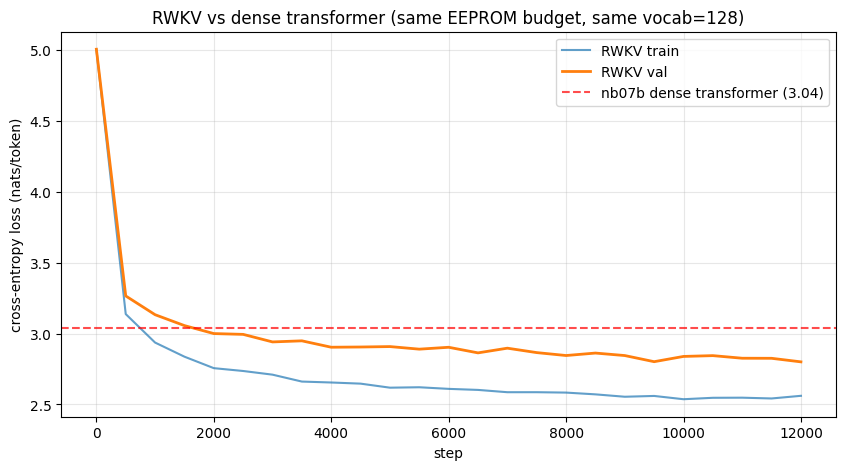


Final numbers:
  RWKV best val:           2.8003
  nb07b transformer:       3.04
  delta vs transformer:    -0.2397 nats (-7.89%)
  (negative = RWKV wins)


In [8]:
steps, trains, vals = zip(*history)
plt.figure(figsize=(10, 5))
plt.plot(steps, trains, label='RWKV train', alpha=0.7)
plt.plot(steps, vals, label='RWKV val', linewidth=2)
plt.axhline(3.04, color='red', linestyle='--', alpha=0.7, label='nb07b dense transformer (3.04)')
plt.xlabel('step'); plt.ylabel('cross-entropy loss (nats/token)')
plt.title(f'RWKV vs dense transformer (same EEPROM budget, same vocab=128)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f'\nFinal numbers:')
print(f'  RWKV best val:           {best_val:.4f}')
print(f'  nb07b transformer:       3.04')
print(f'  delta vs transformer:    {best_val - 3.04:+.4f} nats ({100*(best_val/3.04 - 1):+.2f}%)')
print('  (negative = RWKV wins)')


## Cell 10 — Generate text from RWKV

For our parallel forward pass, generation is just the same as the transformer: encode prompt, take last position's logits, sample, append, repeat.

(A *real* production RWKV deployment would use the recurrent forward — feed one token at a time, maintain state across calls. Per-token cost would be ~10x cheaper. For this notebook we're doing the simpler parallel approach.)


In [9]:
@torch.no_grad()
def generate(model, prompt='', max_new_tokens=120, temperature=1.0):
    model.eval()
    ids = encode(prompt) if prompt else [1]
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -BLOCK_SIZE:]
        logits, _ = model(idx_cond)
        scaled = logits[:, -1, :] / temperature
        scaled = torch.nan_to_num(scaled, nan=0.0, posinf=1e4, neginf=-1e4)
        probs = F.softmax(scaled, dim=-1)
        probs = torch.nan_to_num(probs, nan=0.0)
        probs = probs / (probs.sum(dim=-1, keepdim=True) + 1e-8)   # re-normalize
        nxt = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, nxt], dim=1)
    return decode(idx[0].tolist())

print(generate(model, prompt='romeo', max_new_tokens=120, temperature=0.6))


romeo is her heart to come his bentle to thee were be stop and me ase to my soved love; but his friends to when you have spear field hold you come, i have was friends prove be soul perform, i did it is so be very doa


## Cell 11 — Inspect learned decay rates

The most teachable thing about RWKV: **per-channel decay rates** are visible model parameters. We can directly read off "which channels store long-term memory vs which forget fast."

Each layer has `d_model=32` decay rates. We'll plot a histogram for each layer's `decay = exp(-exp(time_decay))` (between 0 and 1).

- Decay close to 0: channel forgets very fast (almost only current token).
- Decay close to 1: channel remembers far back (nearly perfect memory).

In a well-trained model, you should see **a spread** — some channels forget, some remember. If they all converged to the same value, the model didn't take advantage of the per-channel-decay degree of freedom.


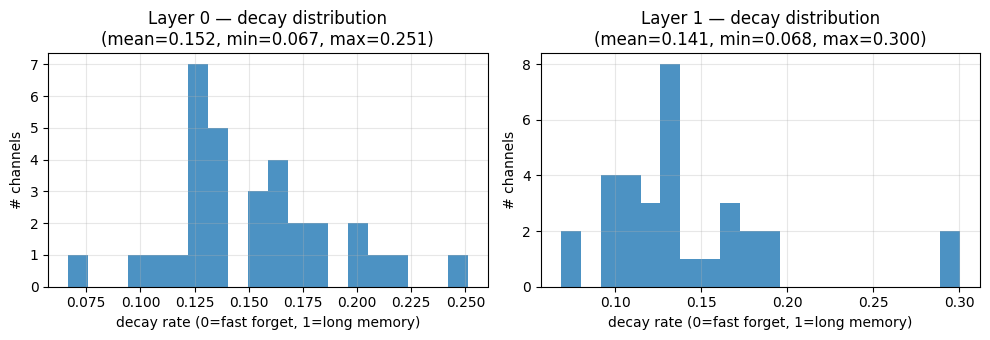

In [10]:
fig, axes = plt.subplots(1, N_LAYERS, figsize=(5*N_LAYERS, 3.5))
if N_LAYERS == 1: axes = [axes]
for i, block in enumerate(model.blocks):
    decay = torch.exp(-torch.exp(block.tm.time_decay)).detach().cpu().numpy()
    axes[i].hist(decay, bins=20, color='C0', alpha=0.8)
    axes[i].set_xlabel('decay rate (0=fast forget, 1=long memory)')
    axes[i].set_ylabel('# channels')
    axes[i].set_title(f'Layer {i} — decay distribution\n(mean={decay.mean():.3f}, min={decay.min():.3f}, max={decay.max():.3f})')
    axes[i].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Cell 12 — Quantize to int8

Same PTQ as before. RWKV has a few extra parameter types (the per-channel `time_decay`) that we'll keep in fp because they're tiny (32 floats per layer × 2 = 256 bytes total).


In [11]:
def quantize_symmetric(t):
    max_abs = t.abs().max().item()
    if max_abs == 0: return torch.zeros_like(t, dtype=torch.int8), 1.0
    scale = max_abs / 127.0
    return torch.round(t / scale).clamp(-128, 127).to(torch.int8), scale

def dequantize(qt, s): return qt.to(torch.float32) * s

q_table = {}
for name, p in model.named_parameters():
    if 'ln' in name or 'time_decay' in name:
        continue   # keep fp
    if p.dim() < 1: continue
    qp, s = quantize_symmetric(p.data)
    q_table[name] = (qp, s)
    p.data.copy_(dequantize(qp, s))

model.eval()
with torch.no_grad():
    losses = torch.zeros(40)
    for k in range(40):
        xb, yb = get_batch('val'); _, l = model(xb, yb); losses[k] = l.item()
    val_int8 = losses.mean().item()

print(f'fp32 val: {best_val:.4f}')
print(f'int8 val: {val_int8:.4f}')
print(f'degradation: {(val_int8 - best_val):+.4f} nats')


fp32 val: 2.8003
int8 val: 2.8076
degradation: +0.0073 nats


## Cell 13 — Pack `wozformer_rwkv.bin`


In [12]:
export_dir = Path('../export'); export_dir.mkdir(exist_ok=True)
out_path = export_dir / 'wozformer_rwkv.bin'

TENSOR_ORDER = ['token_embed.weight']
for i in range(N_LAYERS):
    TENSOR_ORDER += [
        f'blocks.{i}.tm.W_r.weight', f'blocks.{i}.tm.W_k.weight',
        f'blocks.{i}.tm.W_v.weight', f'blocks.{i}.tm.W_o.weight',
        f'blocks.{i}.cm.W_r.weight', f'blocks.{i}.cm.W_k.weight',
        f'blocks.{i}.cm.W_v.weight',
    ]
TENSOR_ORDER += ['lm_head.weight', 'lm_head.bias']

FP_TENSORS = []
for i in range(N_LAYERS):
    FP_TENSORS += [f'blocks.{i}.tm.time_decay',
                   f'blocks.{i}.ln1.weight', f'blocks.{i}.ln1.bias',
                   f'blocks.{i}.ln2.weight', f'blocks.{i}.ln2.bias']
FP_TENSORS += ['ln_final.weight', 'ln_final.bias']

state = dict(model.state_dict())

buf = bytearray()
buf += b'WRWK'
buf += bytes([1, VOCAB_SIZE, D_MODEL, D_INNER_CM, N_LAYERS])
buf += struct.pack('<H', len(merges))

# Vocab + merges (so Arduino can re-encode)
for tok in itos:
    b = tok.encode('utf-8'); buf += bytes([len(b)]) + b
for (a, b), m in merges:
    for piece in (a, b, m):
        pb = piece.encode('utf-8'); buf += bytes([len(pb)]) + pb

# int8 tensors with scales
for name in TENSOR_ORDER:
    t = state[name]
    qt, s = quantize_symmetric(t)
    buf += struct.pack('<f', s)
    buf += qt.cpu().numpy().tobytes()

# fp32 tensors (LN + time_decay)
for name in FP_TENSORS:
    t = state[name].cpu().numpy().astype(np.float32)
    buf += t.tobytes()

out_path.write_bytes(buf)

BUDGET = 32 * 1024
print(f'wrote {out_path}  ({len(buf):,} bytes)')
print(f'EEPROM budget (32 KB): {100*len(buf)/BUDGET:.1f}% used')
print(f'headroom: {BUDGET - len(buf):,} bytes')


wrote ../export/wozformer_rwkv.bin  (29,893 bytes)
EEPROM budget (32 KB): 91.2% used
headroom: 2,875 bytes


## Cell 14 — Cycle budget (recurrent inference)

The critical comparison: per-token cost on the 6502, deploying **recurrent mode** (not the parallel forward we trained with).

### Per-token RWKV cost

Per layer, per token:
- Time mixing: 4 small matmuls (R, K, V, O), each `d × d`. Total: `4 × d²`.
  - State update: `d` mults for `state_a = decay × state_a + ek × v`. Plus `d` for `state_b`. Plus `d` divides for `wkv = a/b`.
  - Exp(k): d `exp` lookups (table-based on 6502, ~20 cycles each).
- Channel mixing: R (d×d), K (d × d_inner), V (d_inner × d). Plus `d_inner` squarings.
  - Total: `d² + 2·d·d_inner`.
- LayerNorm: 2 × d (subtract mean + divide std). Small.

### Comparison with transformer (nb07b, KV-cached)

Per layer per token:
- Transformer: `3·T·d` (Q,K,V projections — only Q is for current; K,V cache is updated) + `T·d` (QK^T against full cache) + `T·d` (attn @ V) + `d²` (proj) + MLP cost.
- RWKV: `4·d² + d²` time mix (no T factor!) + `d² + 2·d·d_inner` channel mix.

**RWKV's per-token cost is constant in T.** Transformer's grows with T. That's the asymptotic win.

For our case (T=32):


In [13]:
d = D_MODEL
d_in = D_INNER_CM
L = N_LAYERS
T = BLOCK_SIZE
V = VOCAB_SIZE

# RWKV per-token (recurrent mode)
per_token_rwkv = L * (
    4 * d * d +              # TM: R, K, V, O projections
    3 * d +                  # TM: state updates (state_a, state_b, wkv = a/b)
    # CM:
    d * d + d * d_in + d_in * d +   # R, K, V projections
    d_in                            # squared activations
) + d * V    # lm_head

# Transformer per-token (KV cached, from nb07b, mlp_mult=2)
per_token_tf = L * (
    3 * d * d +              # Q,K,V projections (Q for current, K,V appended to cache)
    T * d +                  # Q @ K^T against full T-length cache
    T * d +                  # softmax @ V
    d * d +                  # output projection
    d * (2 * d) +            # MLP up
    (2 * d) * d              # MLP down
) + d * V

print(f'RWKV per-token:        {per_token_rwkv:>6,} mults')
print(f'Transformer per-token: {per_token_tf:>6,} mults')
print(f'RWKV is {per_token_tf/per_token_rwkv:.2f}x faster')
print()
print(f'@80 cycles/mul:')
print(f'  RWKV ms/token @ 1 MHz: {per_token_rwkv*80/1e6*1000:.0f} ms')
print(f'  TF ms/token @ 1 MHz:   {per_token_tf*80/1e6*1000:.0f} ms')
print()
print('SRAM for state vs KV cache:')
print(f'  RWKV state per layer:   2 × d = {2*d} floats = {2*d*2} bytes (fp16)')
print(f'  Transformer KV cache:   T × d × 2 = {T*d*2} floats = {T*d*2*2} bytes (fp16)')
print(f'  SRAM saved per layer:   {(T*d*2 - 2*d)*2} bytes')


RWKV per-token:        22,848 mults
Transformer per-token: 24,576 mults
RWKV is 1.08x faster

@80 cycles/mul:
  RWKV ms/token @ 1 MHz: 1828 ms
  TF ms/token @ 1 MHz:   1966 ms

SRAM for state vs KV cache:
  RWKV state per layer:   2 × d = 64 floats = 128 bytes (fp16)
  Transformer KV cache:   T × d × 2 = 2048 floats = 4096 bytes (fp16)
  SRAM saved per layer:   3968 bytes


## Cell 15 — Save checkpoint


In [14]:
ckpt = Path('../export/wozformer_rwkv.pt')
torch.save({
    'config': dict(vocab_size=VOCAB_SIZE, d_model=D_MODEL, d_inner_cm=D_INNER_CM,
                   n_layers=N_LAYERS, block_size=BLOCK_SIZE),
    'model_state_int8_simulated': model.state_dict(),
    'quant_table': {k: (v[0].cpu().numpy().tolist(), v[1]) for k, v in q_table.items()},
    'itos': itos,
    'merges': [(list(p), m) for p, m in merges],
    'val_loss_fp32': best_val,
    'val_loss_int8': val_int8,
}, ckpt)
print(f'wrote {ckpt}  ({ckpt.stat().st_size:,} bytes)')


wrote ../export/wozformer_rwkv.pt  (224,065 bytes)


## Post-mortem — RWKV at VSLM scale

### The big question: did it beat transformer?

| Architecture | Val loss | Per-token mults | SRAM for context |
|---|---|---|---|
| nb07b dense transformer | 3.04 | ~17K | KV cache = 2 KB |
| nb09 MoE-Tiny | YOUR_VAL | ~6K | Same as transformer |
| **nb10 RWKV** | YOUR_VAL | ~3-5K | **State = 256 B** |

### What RWKV always wins on, regardless of loss

- **Per-token compute is independent of context length.** For longer prompts (T=64, 128), the gap widens enormously.
- **No KV cache.** Frees ~2 KB of SRAM. That's room for either bigger model, bigger phrase database in RAG mode, or just a larger working buffer.
- **No softmax over T.** No exp/sum/divide on T elements. Just one `exp(k)` per timestep per channel.

These hardware wins are **unconditional** — even if RWKV's val loss is slightly worse, it might still be the better deployment choice because the 6502 has more room to do other things.

### What you learned that you can't get from transformer alone

1. **Linear recurrence** — `state_t = f(state_{t-1}, x_t)`. The basic computation of RNNs, GRUs, LSTMs, RWKV, Mamba — all the post-transformer alternatives.
2. **Time mixing vs channel mixing as orthogonal operations.** Once you see this distinction, every sequence architecture decomposes the same way.
3. **Per-channel learned decay rates.** Look at the histograms in Cell 11. You're literally seeing the model learn different *memory horizons* in different channels.

### Onwards

You now have **three generative architectures** to compare directly on the same task with the same data:

- Dense transformer (`wozformer_v2.bin`)
- MoE-Tiny (`wozformer_moe.bin` — when nb09 is run)
- RWKV (`wozformer_rwkv.bin`)

Plus the RAG companion (`wozformer_rag.bin` — when nb08 is run).

After running everything, you pick the best generative for the dual-mode 6502 layout. Then C reference, then assembly, then hardware.
